# Deep Learning Model

## Gene representations

Two fully data-driven, no-external-download embedding sources (`src/features/gene_embeddings.py`):

1. **Co-expression embedding** — each gene's correlation profile against 500 landmark highly-variable genes, computed on control cells, PCA-reduced to 32 dims. Available for *every* measured gene, including ones never individually perturbed — a self-contained proxy for a gene-gene functional-similarity network (the same intuition behind STRING/co-expression priors used by GEARS/TxPert).
2. **Perturbation-response embedding** — the HVG-space pseudobulk delta induced by a gene's own single-gene perturbation, PCA-reduced to 32 dims. Only available for genes with single-gene perturbation data in the *training* split; zero-filled otherwise.

A perturbation's final feature is `[sum, |diff|]` of its one or two genes' embeddings (permutation-invariant, and naturally handles single-gene perturbations as a gene paired with a zero vector).

## Architecture

Control-cell expression (2000 HVGs) → small encoder → 128-d latent, concatenated with the 128-d perturbation embedding → MLP decoder → predicted 2000-d expression delta. Trained with AdamW, early stopping on a held-out slice of training perturbations. See `src/models/perturbation_model.py` and `scripts/05_train_model.py`.

<Axes: title={'center': 'MLP training curve'}, xlabel='epoch'>

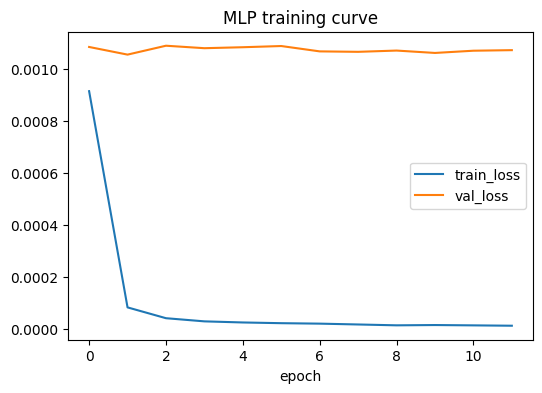

In [1]:
import pandas as pd
curve = pd.read_csv('../results/tables/training_curve_full.csv')
curve.plot(x='epoch', y=['train_loss', 'val_loss'], figsize=(6,4), title='MLP training curve')

## Model comparison, including the embedding ablation

Does the perturbation-response signal (a stand-in for biological/KG priors used by GEARS/Scouter/TxPert) actually help beyond static co-expression structure?

In [2]:
comparison = pd.read_csv('../results/tables/model_comparison.csv')
pd.set_option('display.width', 200)
comparison.round(3)

,model,category,pearson_delta,mse,de_pearson_delta,direction_accuracy,n_perturbations
0,No-perturbation,test_combo_0_unseen,0.000,0.007,0.000,0.000,22
1,No-perturbation,test_combo_1_unseen,0.000,0.008,0.000,0.000,51
2,No-perturbation,test_combo_2_unseen,0.000,0.012,0.000,0.000,5
3,No-perturbation,test_unseen_single,0.000,0.003,0.000,0.000,26
4,No-perturbation,"train (seen, sanity check)",0.000,0.005,0.000,0.000,132
5,Mean-shift,test_combo_0_unseen,0.573,0.005,0.652,0.851,22
6,Mean-shift,test_combo_1_unseen,0.395,0.007,0.373,0.786,51
7,Mean-shift,test_combo_2_unseen,0.398,0.011,0.379,0.824,5
8,Mean-shift,test_unseen_single,0.337,0.003,0.336,0.762,26
9,Mean-shift,"train (seen, sanity check)",0.506,0.004,0.555,0.817,132


**Findings:**

- On `test_combo_0_unseen` (both genes individually characterized), adding the perturbation-response embedding is a large win: Ridge goes from 0.65 → 0.90 Pearson-Δ, MLP similarly reaches 0.90.
- On `test_combo_2_unseen` (neither gene ever perturbed individually — only 5 perturbations), the combined embedding is *worse* than co-expression-only (Ridge: 0.41 vs. 0.66). The model leans on the perturbation-response feature during training; when that feature is entirely absent (zero-filled) for both genes, predictions degrade below a model that never had access to it. This is a genuine, small-n finding that motivates exactly why external knowledge-graph or LLM-derived embeddings (GEARS, Scouter, TxPert) matter: they provide informative gene representations even for genes that were never perturbed, which our purely data-driven embedding cannot.
- On `test_unseen_single` (a genuinely new single gene), all models are much weaker (~0.25–0.35 Pearson-Δ) — the hardest, most realistic generalization regime.
- The deep MLP and Ridge perform comparably overall. This is expected given our simplified target: we predict the *population-level pseudobulk* response (same target for every control cell of a given perturbation), so the model's cell-state branch has limited signal to exploit. A richer per-cell architecture (predicting single-cell response distributions, as in GEARS/scGen) would likely show a larger advantage for the deep model.

In [3]:
ensemble = pd.read_csv('../results/tables/ensemble_metrics.csv')
ensemble.round(3)

,model,category,pearson_delta,mse,de_pearson_delta,direction_accuracy,n_perturbations
0,"MLP ensemble (5 seeds, mean)",test_combo_0_unseen,0.916,0.001,0.954,0.993,22
1,"MLP ensemble (5 seeds, mean)",test_combo_1_unseen,0.690,0.003,0.736,0.872,51
2,"MLP ensemble (5 seeds, mean)",test_combo_2_unseen,0.391,0.011,0.452,0.816,5
3,"MLP ensemble (5 seeds, mean)",test_unseen_single,0.315,0.003,0.334,0.738,26
4,"MLP ensemble (5 seeds, mean)",train,0.965,0.000,0.984,0.998,132


Averaging 5 independently-seeded MLPs (the uncertainty ensemble used for the virtual screen) gives a small but consistent improvement over any single model.